# Prophet Facebook's Forecasting Tool

**Prophet** is an open-source forecasting tool developed by Facebook/Meta, designed for business time series with:
- Strong seasonal effects
- Multiple seasonalities (daily, weekly, yearly)
- Holiday effects
- Trend changepoints
- Missing data and outliers

Prophet requires **minimal expertise** and works well for **non-technical analysts**.

## The Prophet Model

Prophet uses an **additive decomposition model**:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

| Component | Symbol | Description |
|-----------|--------|-------------|
| Trend | $g(t)$ | Non-periodic changes |
| Seasonality | $s(t)$ | Periodic changes |
| Holidays | $h(t)$ | Irregular schedules |
| Error | $\epsilon_t$ | Idiosyncratic noise $\sim \mathcal{N}(0, \sigma^2)$ |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    from prophet import Prophet
    from prophet.diagnostics import cross_validation, performance_metrics
    from prophet.plot import plot_cross_validation_metric
    PROPHET_AVAILABLE = True
except ImportError:
    try:
        from fbprophet import Prophet
        PROPHET_AVAILABLE = True
    except ImportError:
        PROPHET_AVAILABLE = False
        print("Install: pip install prophet")

# Prophet requires 'ds' (datestamp) and 'y' (value) columns
from statsmodels.datasets import get_rdataset
raw = get_rdataset('AirPassengers').data
raw.index = pd.date_range(start='1949-01', periods=len(raw), freq='MS')

df = pd.DataFrame({
    'ds': raw.index,
    'y':  raw['value'].values
})

print(df.head())
print(f"Shape: {df.shape}")

          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121
Shape: (144, 2)


## Trend Component $g(t)$

Prophet supports two trend models:

### 1. Linear Trend (with changepoints)

$$g(t) = (k + \mathbf{a}(t)^T \boldsymbol{\delta}) t + (m + \mathbf{a}(t)^T \boldsymbol{\gamma})$$

where:
- $k$ = base growth rate
- $\boldsymbol{\delta} \in \mathbb{R}^S$ = rate adjustments at changepoints
- $m$ = base offset
- $\mathbf{a}(t) \in \{0,1\}^S$ = indicator vector ($a_j(t)=1$ if $t \geq s_j$)
- $s_1, \ldots, s_S$ = changepoint locations
- $\gamma_j = -s_j \delta_j$ ensures continuity

Prior on changepoints: $\delta_j \sim \text{Laplace}(0, \lambda)$ sparse changepoints

### 2. Logistic Growth (saturating)

$$g(t) = \frac{C(t)}{1 + \exp(-(k + \mathbf{a}(t)^T \boldsymbol{\delta})(t - (m + \mathbf{a}(t)^T \boldsymbol{\gamma})))}$$

where $C(t)$ is the **carrying capacity** (user-specified or time-varying).

## Seasonality Component $s(t)$

Prophet models seasonality with **Fourier series**:

$$s(t) = \sum_{n=1}^{N} \left(a_n \cos\left(\frac{2\pi n t}{P}\right) + b_n \sin\left(\frac{2\pi n t}{P}\right)\right)$$

where:
- $P$ = period (365.25 for yearly, 7 for weekly)
- $N$ = number of Fourier terms (controls smoothness)
- $[a_1, b_1, \ldots, a_N, b_N] \sim \mathcal{N}(0, \sigma_s^2)$ regularisation prior

Yearly seasonality: $P = 365.25$, $N = 10$ by default
Weekly seasonality: $P = 7$, $N = 3$ by default

In [2]:
if PROPHET_AVAILABLE:
    # Basic Prophet model
    m = Prophet(
        growth='linear',
        seasonality_mode='multiplicative',  # better for AirPassengers (variance grows)
        yearly_seasonality=True,
        weekly_seasonality=False,           # monthly data no weekly pattern
        daily_seasonality=False,
        changepoint_prior_scale=0.05,       # λ controls flexibility of trend
        seasonality_prior_scale=10.0,       # σ_s controls amplitude of seasonality
    )
    
    train = df[df['ds'] < '1960-01-01']
    m.fit(train)
    
    # Make future dataframe
    future = m.make_future_dataframe(periods=24, freq='MS')
    forecast = m.predict(future)
    
    print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

14:31:15 - cmdstanpy - INFO - Chain [1] start processing


14:31:15 - cmdstanpy - INFO - Chain [1] done processing


            ds        yhat  yhat_lower  yhat_upper
146 1961-03-01  485.513594  472.080253  498.301409
147 1961-04-01  470.793712  458.212950  483.211499
148 1961-05-01  477.059181  464.204163  490.118282
149 1961-06-01  554.067351  540.563833  568.381896
150 1961-07-01  614.349114  600.040730  627.484144
151 1961-08-01  616.913237  604.090836  630.294260
152 1961-09-01  529.559079  516.895641  543.155425
153 1961-10-01  462.393155  449.981638  475.711340
154 1961-11-01  404.821632  391.297755  419.329146
155 1961-12-01  450.657837  437.333533  464.032891


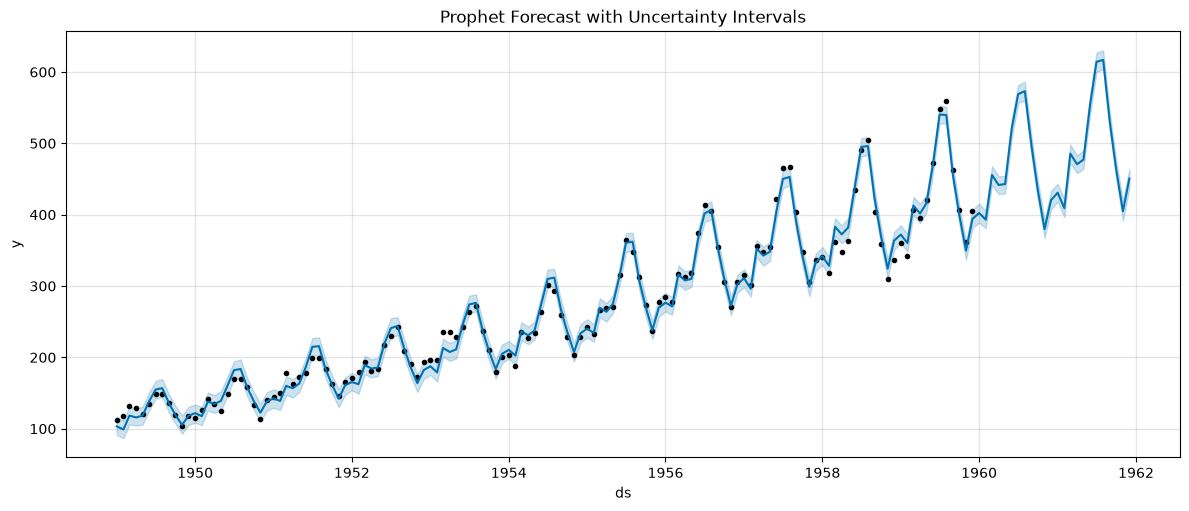

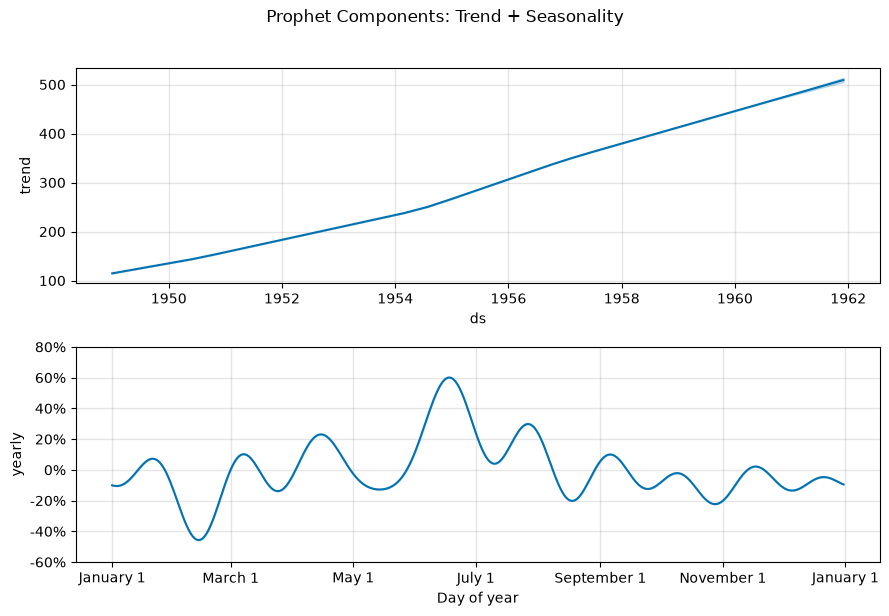

In [3]:
if PROPHET_AVAILABLE:
    # Plot forecast with uncertainty intervals
    fig = m.plot(forecast, figsize=(12, 5))
    plt.title('Prophet Forecast with Uncertainty Intervals')
    plt.show()
    
    # Plot components
    fig2 = m.plot_components(forecast)
    plt.suptitle('Prophet Components: Trend + Seasonality', y=1.02)
    plt.tight_layout()
    plt.show()

## Holiday Effects $h(t)$

$$h(t) = Z(t) \boldsymbol{\kappa}, \quad \boldsymbol{\kappa} \sim \mathcal{N}(0, \nu^2)$$

where $Z(t)$ is an indicator matrix for holidays and windows around them.

In [4]:
if PROPHET_AVAILABLE:
    # Custom holidays
    holidays = pd.DataFrame({
        'holiday': 'summer_peak',
        'ds': pd.to_datetime(['1949-07-01', '1950-07-01', '1951-07-01',
                              '1952-07-01', '1953-07-01', '1954-07-01',
                              '1955-07-01', '1956-07-01', '1957-07-01',
                              '1958-07-01', '1959-07-01']),
        'lower_window': 0,
        'upper_window': 1,
    })
    
    m_holiday = Prophet(
        holidays=holidays,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05
    )
    m_holiday.fit(train)
    forecast_h = m_holiday.predict(future)
    print("Holiday model fitted successfully")

14:31:16 - cmdstanpy - INFO - Chain [1] start processing


14:31:16 - cmdstanpy - INFO - Chain [1] done processing


Holiday model fitted successfully


## Changepoint Detection

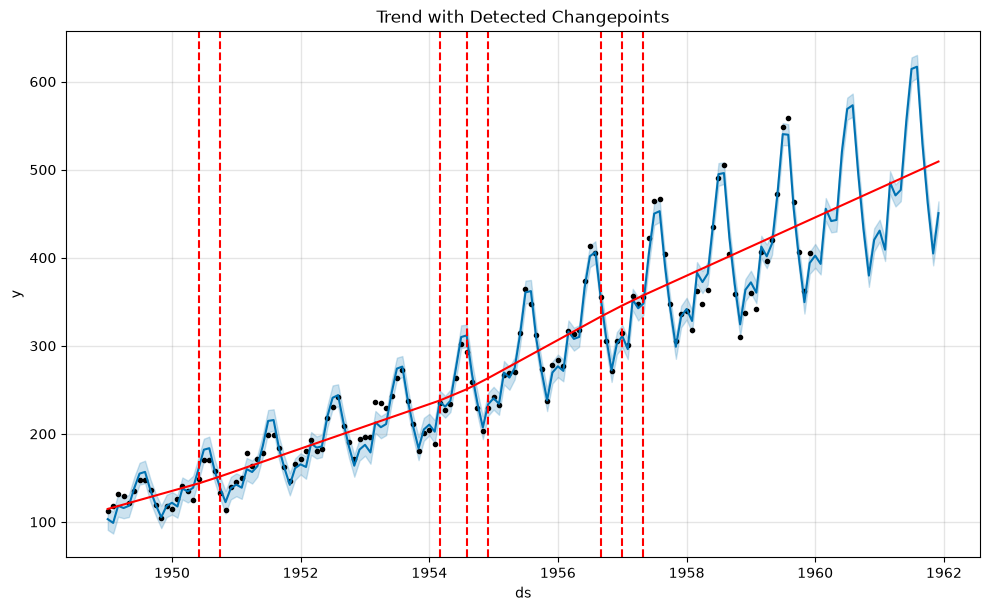

Detected changepoints:
4     1949-05-01
8     1949-09-01
12    1950-01-01
17    1950-06-01
21    1950-10-01
25    1951-02-01
29    1951-06-01
33    1951-10-01
37    1952-02-01
42    1952-07-01
46    1952-11-01
50    1953-03-01
54    1953-07-01
58    1953-11-01
62    1954-03-01
67    1954-08-01
71    1954-12-01
75    1955-04-01
79    1955-08-01
83    1955-12-01
87    1956-04-01
92    1956-09-01
96    1957-01-01
100   1957-05-01
104   1957-09-01
Name: ds, dtype: datetime64[ns]


In [5]:
if PROPHET_AVAILABLE:
    from prophet.plot import add_changepoints_to_plot
    
    fig = m.plot(forecast)
    a = add_changepoints_to_plot(fig.gca(), m, forecast)
    plt.title('Trend with Detected Changepoints')
    plt.show()
    
    print("Detected changepoints:")
    print(m.changepoints)

## Cross-Validation in Prophet

Prophet has built-in **time series cross-validation** using simulated historical forecasts:

- `initial`: size of initial training period
- `period`: spacing between cutoff dates
- `horizon`: forecast horizon to evaluate

14:31:19 - cmdstanpy - INFO - Chain [1] start processing
14:31:19 - cmdstanpy - INFO - Chain [1] start processing


14:31:19 - cmdstanpy - INFO - Chain [1] start processing
14:31:19 - cmdstanpy - INFO - Chain [1] start processing


14:31:20 - cmdstanpy - INFO - Chain [1] done processing
14:31:20 - cmdstanpy - INFO - Chain [1] start processing
14:31:20 - cmdstanpy - INFO - Chain [1] start processing
14:31:20 - cmdstanpy - INFO - Chain [1] start processing
14:31:20 - cmdstanpy - INFO - Chain [1] start processing


14:31:20 - cmdstanpy - INFO - Chain [1] start processing
14:31:20 - cmdstanpy - INFO - Chain [1] done processing


14:31:20 - cmdstanpy - INFO - Chain [1] start processing


...

14:31:22 - cmdstanpy - INFO - Chain [1] done processing


14:31:22 - cmdstanpy - INFO - Chain [1] done processing


14:31:23 - cmdstanpy - INFO - Chain [1] done processing


14:31:37 - cmdstanpy - INFO - Chain [1] done processing


  horizon        mae      mape       rmse
0 37 days  15.051908  0.057616  18.434864
1 41 days  14.796619  0.056688  18.377803
2 42 days  15.467218  0.056952  19.206652
3 46 days  14.476762  0.053772  18.333304
4 48 days  12.269910  0.047176  16.058969
5 52 days  12.366696  0.050407  15.483816
6 53 days  12.682781  0.048761  15.755581
7 54 days  12.585548  0.048741  15.686337
8 57 days  13.667897  0.051522  17.110785
9 58 days  14.014169  0.051556  17.498432


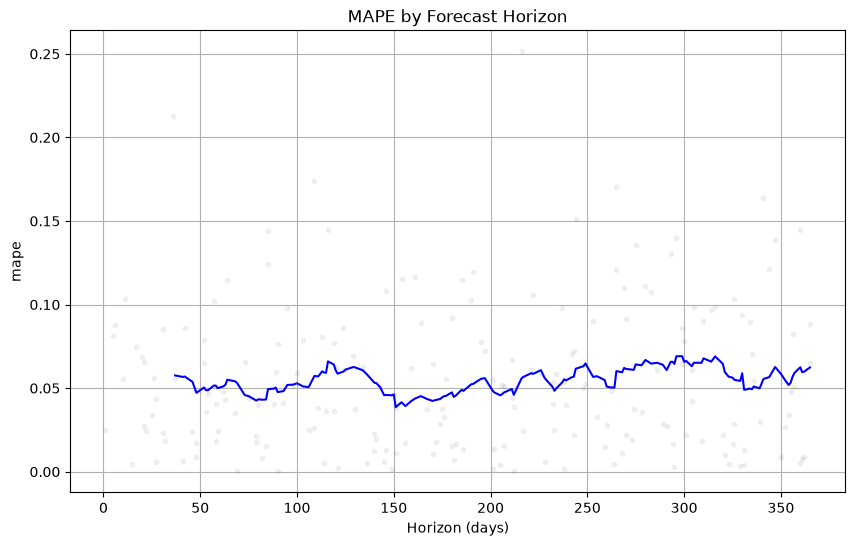

In [6]:
if PROPHET_AVAILABLE:
    df_cv = cross_validation(
        m,
        initial='730 days',   # 2 years training
        period='180 days',    # evaluate every 6 months
        horizon='365 days',   # forecast 1 year ahead
        parallel='processes'
    )
    
    df_perf = performance_metrics(df_cv)
    print(df_perf[['horizon', 'mae', 'mape', 'rmse']].head(10))
    
    fig = plot_cross_validation_metric(df_cv, metric='mape')
    plt.title('MAPE by Forecast Horizon')
    plt.show()

## Hyperparameter Tuning

In [7]:
if PROPHET_AVAILABLE:
    import itertools
    
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    }
    
    all_params = [dict(zip(param_grid.keys(), v)) 
                  for v in itertools.product(*param_grid.values())]
    
    rmses = []
    for params in all_params:
        mod = Prophet(**params, seasonality_mode='multiplicative').fit(train)
        df_cv_tmp = cross_validation(mod, initial='730 days', period='180 days',
                                     horizon='365 days', parallel='processes')
        df_p = performance_metrics(df_cv_tmp, rolling_window=1)
        rmses.append(df_p['rmse'].values[0])
    
    best_params = all_params[np.argmin(rmses)]
    print(f"Best params: {best_params}")
    print(f"Best RMSE:   {min(rmses):.4f}")

14:31:37 - cmdstanpy - INFO - Chain [1] start processing


14:31:37 - cmdstanpy - INFO - Chain [1] done processing


14:31:37 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Optimization terminated abnormally. Falling back to Newton.


14:31:37 - cmdstanpy - INFO - Chain [1] start processing


...

14:34:14 - cmdstanpy - INFO - Chain [1] done processing


14:34:14 - cmdstanpy - INFO - Chain [1] done processing


14:34:14 - cmdstanpy - INFO - Chain [1] done processing


Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1}
Best RMSE:   18.8758


14:34:31 - cmdstanpy - INFO - Chain [1] done processing


## NeuralProphet

**NeuralProphet** extends Prophet with neural network components:
- Auto-regression (AR-Net) for residual autocorrelation
- Lagged regressors
- Multi-step ahead forecasting
- PyTorch backend

In [8]:
try:
    from neuralprophet import NeuralProphet
    
    m_np = NeuralProphet(
        n_forecasts=12,      # 12-step horizon
        n_lags=24,           # AR-Net lags
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        learning_rate=0.01
    )
    
    metrics = m_np.fit(df, freq='MS', epochs=200)
    future_np = m_np.make_future_dataframe(df, periods=12)
    forecast_np = m_np.predict(future_np)
    print("NeuralProphet forecast generated")

except ImportError:
    print("Install: pip install neuralprophet")
    print("Docs: https://neuralprophet.com/")

Install: pip install neuralprophet
Docs: https://neuralprophet.com/


## When to Use Prophet

✅ **Good for:**
- Business metrics (sales, revenue, web traffic)
- Daily/weekly/yearly seasonality
- Known holidays and events
- Non-technical users
- Rapid prototyping

❌ **Not ideal for:**
- High-frequency data (seconds/minutes)
- Strong autocorrelation
- Many interrelated series
- When SARIMA or LightGBM already works well

---

## Additional Learning Resources

### Papers
- **Prophet paper** Taylor & Letham (2018): https://peerj.com/preprints/3190/
- **NeuralProphet** Triebe et al. (2021): https://arxiv.org/abs/2111.15397

### Docs
- Prophet documentation: https://facebook.github.io/prophet/
- NeuralProphet docs: https://neuralprophet.com/

### Tutorials
- Prophet quick start: https://facebook.github.io/prophet/docs/quick_start.html
- Towards Data Science Prophet guide: https://towardsdatascience.com/prophet-the-facebook-forecasting-tool

### Videos
- Rob Hyndman on ETS vs ARIMA vs Prophet: https://www.youtube.com/watch?v=yQjfr9LQWZM